In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/2goa_human.gaf
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/8hp.obo
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/7doid.obo.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/1go-basic.obo
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/6chebi.obo.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/4human resource uniprot.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg/network.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg/dgroup.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg/drug .txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg/variant.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg/disease.txt
/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/3gene_info/gene_info
/

In [3]:
# Install required libraries (run once in Kaggle)
!pip install obonet networkx pyvis pandas matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import networkx as nx
import obonet
import re
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 15.0 MB/s eta 0:00:0000:01
✅ All libraries loaded


# DIABETES SEED IDs — the anchor entire KG

In [4]:
# ─────────────────────────────────────────────────────────────────────
# DIABETES SEED IDs — the anchor entire KG
# These are well-known diabetes genes from NCBI/literature
# ─────────────────────────────────────────────────────────────────────

DIABETES_GENES = {
    'INS', 'INSR', 'IRS1', 'IRS2', 'GCK', 'GLUT2', 'SLC2A2',
    'PPARG', 'TCF7L2', 'KCNJ11', 'ABCC8', 'HNF1A', 'HNF4A',
    'PTPN1', 'LEPR', 'LEP', 'ADIPOQ', 'RETN', 'FTO', 'MC4R',
    'GLP1R', 'GCGR', 'PDX1', 'PAX4', 'PAX6', 'NEUROD1',
    'G6PC', 'PCK1', 'FOXO1', 'AKT1', 'AKT2', 'PIK3CA',
    'MAPK1', 'MAPK3', 'MTOR', 'AMPK', 'PRKAA1', 'PRKAA2'
}

# NCBI Gene IDs for diabetes genes (for matching gene_info & BioGRID)
DIABETES_GENE_IDS = {
    3630, 3643, 3667, 8660, 2645, 6513, 5467, 6934, 3659,
    3784, 6833, 6927, 2308, 5770, 3952, 3953, 9370, 56729,
    8895, 55660, 2740, 2642, 3651, 5078, 7080, 4760, 2538,
    5106, 2308, 207, 208, 5290, 5594, 5595, 2475, 5562, 5563
}

# DOID for diabetes (Disease Ontology IDs)
DIABETES_DOID = {
    'DOID:9351',   # diabetes mellitus
    'DOID:9352',   # type 2 diabetes
    'DOID:9353',   # type 1 diabetes
    'DOID:11716',  # gestational diabetes
    'DOID:0111060' # MODY
}

# HPO terms for diabetes phenotypes
DIABETES_HPO = {
    'HP:0000819', # Diabetes mellitus
    'HP:0000822', # Hypertension (complication)
    'HP:0001513', # Obesity
    'HP:0003074', # Hyperglycemia
    'HP:0001943', # Hypoglycemia
    'HP:0000858', # Irregular menstruation (PCOS-diabetes link)
    'HP:0004904', # Maturity-onset diabetes
    'HP:0000842', # Hyperinsulinemia
}

print(f"✅ Seed genes: {len(DIABETES_GENES)}")
print(f"✅ Seed DOID terms: {len(DIABETES_DOID)}")
print(f"✅ Seed HPO terms: {len(DIABETES_HPO)}")

✅ Seed genes: 38
✅ Seed DOID terms: 5
✅ Seed HPO terms: 8


# Path Setup

In [38]:

BASE = "/kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset"  

PATHS = {
    'gene_info'  : f"{BASE}/3gene_info/gene_info",
    'goa'        : f"{BASE}/2goa_human.gaf",
    'go_obo'     : f"{BASE}/1go-basic.obo",
    'uniprot'    : f"{BASE}/4human resource uniprot.txt",
    'chebi'      : f"{BASE}/6chebi.obo.txt",
    'doid'       : f"{BASE}/7doid.obo.txt",
    'hpo'        : f"{BASE}/8hp.obo",
    'biogrid'    : f"{BASE}/10BIOGRID-ALL-LATEST.tab2/BIOGRID-ALL-5.0.256.tab2.txt",
    'kegg'       : f"{BASE}/11kegg",  # adjust if it's a folder
}

# Quick existence check
for name, path in PATHS.items():
    status = "✅" if os.path.exists(path) else "❌ NOT FOUND"
    print(f"{status}  {name}: {path}")

✅  gene_info: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/3gene_info/gene_info
✅  goa: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/2goa_human.gaf
✅  go_obo: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/1go-basic.obo
✅  uniprot: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/4human resource uniprot.txt
✅  chebi: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/6chebi.obo.txt
✅  doid: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/7doid.obo.txt
✅  hpo: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/8hp.obo
✅  biogrid: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/10BIOGRID-ALL-LATEST.tab2/BIOGRID-ALL-5.0.256.tab2.txt
✅  kegg: /kaggle/input/datasets/muhammadjunaid20159/bioinformatics/Dataset/11kegg


# Parse Gene Info

In [6]:
def parse_gene_info_chunked(path, chunk_size=200_000):
    """
    Read gene_info in chunks — never loads full file into RAM.
    Each chunk is filtered immediately and discarded.
    """
    print("📄 Parsing gene_info in chunks...")

    col_names = [
        'tax_id','GeneID','Symbol','LocusTag','Synonyms',
        'dbXrefs','chromosome','map_location','description',
        'type_of_gene','Symbol_auth','Full_name_auth',
        'Nomenclature_status','Other_designations',
        'Modification_date','Feature_type'
    ]

    kept_chunks = []
    total_rows  = 0
    chunk_num   = 0

    reader = pd.read_csv(
        path,
        sep='\t',
        comment='#',          # skip header line
        names=col_names,
        chunksize=chunk_size,
        low_memory=False,
        dtype={
            'tax_id' : 'Int32',
            'GeneID' : 'Int64',
            'Symbol' : 'str'
        }
    )

    for chunk in reader:
        chunk_num  += 1
        total_rows += len(chunk)

        # ── Filter 1: human only (drops ~98% of rows immediately) ──
        chunk = chunk[chunk['tax_id'] == 9606]

        # ── Filter 2: diabetes genes ────────────────────────────────
        mask = (
            chunk['Symbol'].isin(DIABETES_GENES) |
            chunk['GeneID'].isin(DIABETES_GENE_IDS)
        )
        chunk = chunk[mask]

        if len(chunk) > 0:
            kept_chunks.append(chunk)

        # Progress every 10 chunks
        if chunk_num % 10 == 0:
            found = sum(len(c) for c in kept_chunks)
            print(f"  Chunk {chunk_num:3d} | Rows scanned: {total_rows:,} | Diabetes genes found: {found}")

    if not kept_chunks:
        print("⚠️  No matching genes found! Check your paths and seed lists.")
        return pd.DataFrame()

    df = pd.concat(kept_chunks, ignore_index=True)
    print(f"\n  ✅ Done. Scanned {total_rows:,} rows total.")

    gene_nodes = pd.DataFrame({
        'node_id'    : 'Gene:' + df['GeneID'].astype(str),
        'name'       : df['Symbol'],
        'full_name'  : df['description'],
        'node_type'  : 'Gene',
        'chromosome' : df['chromosome'],
        'gene_type'  : df['type_of_gene'],
        'ncbi_id'    : df['GeneID'].astype(str)
    })

    print(f"  → {len(gene_nodes)} diabetes gene nodes extracted")
    return gene_nodes

gene_nodes = parse_gene_info_chunked(PATHS['gene_info'])
gene_nodes.head()

📄 Parsing gene_info in chunks...
  Chunk  10 | Rows scanned: 2,000,000 | Diabetes genes found: 0
  Chunk  20 | Rows scanned: 4,000,000 | Diabetes genes found: 0
  Chunk  30 | Rows scanned: 6,000,000 | Diabetes genes found: 0
  Chunk  40 | Rows scanned: 8,000,000 | Diabetes genes found: 0
  Chunk  50 | Rows scanned: 10,000,000 | Diabetes genes found: 0
  Chunk  60 | Rows scanned: 12,000,000 | Diabetes genes found: 0
  Chunk  70 | Rows scanned: 14,000,000 | Diabetes genes found: 44
  Chunk  80 | Rows scanned: 16,000,000 | Diabetes genes found: 44
  Chunk  90 | Rows scanned: 18,000,000 | Diabetes genes found: 44
  Chunk 100 | Rows scanned: 20,000,000 | Diabetes genes found: 44
  Chunk 110 | Rows scanned: 22,000,000 | Diabetes genes found: 44
  Chunk 120 | Rows scanned: 24,000,000 | Diabetes genes found: 44
  Chunk 130 | Rows scanned: 26,000,000 | Diabetes genes found: 44
  Chunk 140 | Rows scanned: 28,000,000 | Diabetes genes found: 44
  Chunk 150 | Rows scanned: 30,000,000 | Diabetes gen

,node_id,name,full_name,node_type,chromosome,gene_type,ncbi_id
0,Gene:207,AKT1,AKT serine/threonine kinase 1,Gene,14,protein-coding,207
1,Gene:208,AKT2,AKT serine/threonine kinase 2,Gene,19,protein-coding,208
2,Gene:2308,FOXO1,forkhead box O1,Gene,13,protein-coding,2308
3,Gene:2475,MTOR,mechanistic target of rapamycin kinase,Gene,1,protein-coding,2475
4,Gene:2538,G6PC1,glucose-6-phosphatase catalytic subunit 1,Gene,17,protein-coding,2538


Due to the large size of biomedical datasets, chunk-based data loading was used to efficiently process and filter relevant diabetes-related records without exhausting system memory.

In [7]:
# Check which genes were found vs missing from your seed list
print("FOUND genes:")
found_genes = set(gene_nodes['name'].tolist())
for g in sorted(found_genes):
    print(f"   {g}")

print(f"\n MISSING from seed list (not in NCBI human gene_info):")
missing = DIABETES_GENES - found_genes
for g in sorted(missing):
    print(f"   {g}")

FOUND genes:
   ABCC8
   ADIPOQ
   AKT1
   AKT2
   CPNE3
   FOXO1
   FTO
   G6PC1
   GCGR
   GCK
   GLP1R
   HNF1A
   HNF4A
   INS
   INSR
   IRF1
   IRS1
   IRS2
   KCNJ11
   KCNQ1
   LEP
   LEPR
   MAPK1
   MAPK3
   MC4R
   MTOR
   NEUROD1
   NKX2-1
   PAX4
   PAX6
   PCK1
   PCK2
   PDX1
   PIK3CA
   PPARD
   PPARG
   PRKAA1
   PRKAA2
   PRPF40A
   PTPN1
   RETN
   SLC2A1
   SLC2A2
   TCF7L2

 MISSING from seed list (not in NCBI human gene_info):
   AMPK
   G6PC
   GLUT2


In [19]:
# Common alias mismatches between your seed list and NCBI official symbols
ALIAS_FIXES = {
    'GLUT2'  : 'SLC2A2',   # GLUT2 is the old name, NCBI uses SLC2A2
    'AMPK'   : 'PRKAA1',   # AMPK is a complex; NCBI uses subunit names
    'MAPK1'  : 'MAPK1',    # usually fine
    'MAPK3'  : 'MAPK3',    # usually fine
}

# Update your DIABETES_GENES seed to use NCBI official symbols
DIABETES_GENES_EXPANDED = DIABETES_GENES.copy()

# Add extra well-known diabetes genes (expand coverage)
DIABETES_GENES_EXPANDED.update({
    # Insulin signaling
    'SLC2A2', 'SLC2A4', 'GLUT4',
    # Inflammation (T2D pathway)
    'TNF', 'IL6', 'IL1B', 'CRP',
    # Beta-cell function
    'NKX6-1', 'NKX2-2', 'NEUROG3',
    # Lipid metabolism (T2D comorbidity)
    'APOE', 'APOC3', 'LPL',
    # Oxidative stress
    'SOD1', 'SOD2', 'CAT', 'GPX1',
    # Kidney (diabetic nephropathy)
    'ACE', 'AGT', 'AGTR1',
    # Eye (diabetic retinopathy)
    'VEGFA', 'KDR',
    # Mitochondria
    'UCP1', 'UCP2', 'UCP3',
})

# Also expand NCBI GeneIDs
DIABETES_GENE_IDS.update({
    7124,  # TNF
    3569,  # IL6
    3553,  # IL1B
    1401,  # NKX2-2
    8820,  # NKX6-1
    50674, # NEUROG3
    348,   # APOE
    7040,  # TGFB1
    7422,  # VEGFA
    1636,  # ACE
    183,   # AGT
    6510,  # SLC2A4
    6513,  # SLC2A2
    6647,  # SOD1
    6648,  # SOD2
    847,   # CAT
    2876,  # GPX1
    10371, # UCP2
    51129, # UCP3
})

print(f"✅ Expanded seed: {len(DIABETES_GENES_EXPANDED)} genes")
print(f"✅ Expanded IDs : {len(DIABETES_GENE_IDS)} gene IDs")

✅ Expanded seed: 62 genes
✅ Expanded IDs : 54 gene IDs


In [20]:
def parse_gene_info_chunked(path, chunk_size=200_000):
    print("📄 Parsing gene_info in chunks (expanded gene list)...")

    col_names = [
        'tax_id','GeneID','Symbol','LocusTag','Synonyms',
        'dbXrefs','chromosome','map_location','description',
        'type_of_gene','Symbol_auth','Full_name_auth',
        'Nomenclature_status','Other_designations',
        'Modification_date','Feature_type'
    ]

    kept_chunks = []
    total_rows  = 0

    reader = pd.read_csv(
        path, sep='\t', comment='#',
        names=col_names, chunksize=chunk_size,
        low_memory=False,
        dtype={'tax_id':'Int32','GeneID':'Int64','Symbol':'str'}
    )

    for chunk in reader:
        total_rows += len(chunk)

        # Filter human only first (fastest drop)
        chunk = chunk[chunk['tax_id'] == 9606]

        # Filter diabetes genes (expanded list)
        mask = (
            chunk['Symbol'].isin(DIABETES_GENES_EXPANDED) |
            chunk['GeneID'].isin(DIABETES_GENE_IDS)
        )
        chunk = chunk[mask]

        if len(chunk) > 0:
            kept_chunks.append(chunk)

    df = pd.concat(kept_chunks, ignore_index=True)

    gene_nodes = pd.DataFrame({
        'node_id'    : 'Gene:' + df['GeneID'].astype(str),
        'name'       : df['Symbol'],
        'full_name'  : df['description'],
        'node_type'  : 'Gene',
        'chromosome' : df['chromosome'],
        'gene_type'  : df['type_of_gene'],
        'ncbi_id'    : df['GeneID'].astype(str)
    })

    print(f"  ✅ Scanned: {total_rows:,} total rows")
    print(f"  ✅ Extracted: {len(gene_nodes)} diabetes gene nodes")
    return gene_nodes

# Re-run with expanded list
gene_nodes = parse_gene_info_chunked(PATHS['gene_info'])
gene_nodes.head()

📄 Parsing gene_info in chunks (expanded gene list)...
  ✅ Scanned: 67,739,570 total rows
  ✅ Extracted: 72 diabetes gene nodes


,node_id,name,full_name,node_type,chromosome,gene_type,ncbi_id
0,Gene:183,AGT,angiotensinogen,Gene,1,protein-coding,183
1,Gene:185,AGTR1,angiotensin II receptor type 1,Gene,3,protein-coding,185
2,Gene:207,AKT1,AKT serine/threonine kinase 1,Gene,14,protein-coding,207
3,Gene:208,AKT2,AKT serine/threonine kinase 2,Gene,19,protein-coding,208
4,Gene:345,APOC3,apolipoprotein C3,Gene,11,protein-coding,345


In [21]:
# Show a clean breakdown by chromosome and gene type
print("=" * 45)
print("      GENE NODE COVERAGE REPORT")
print("=" * 45)

print(f"\nTotal gene nodes : {len(gene_nodes)}")

print("\nBy chromosome:")
print(gene_nodes['chromosome'].value_counts().to_string())

print("\nBy gene_type:")
print(gene_nodes['gene_type'].value_counts().to_string())

print("\nFull gene list:")
print(gene_nodes[['name','full_name','chromosome']].to_string(index=False))

      GENE NODE COVERAGE REPORT

Total gene nodes : 72

By chromosome:
chromosome
11    9
3     7
19    7
1     6
6     5
7     5
2     4
17    4
20    4
14    3
13    3
4     3
5     2
8     2
10    2
16    2
22    1
18    1
21    1
12    1

By gene_type:
gene_type
protein-coding    72

Full gene list:
   name                                                              full_name chromosome
    AGT                                                        angiotensinogen          1
  AGTR1                                         angiotensin II receptor type 1          3
   AKT1                                          AKT serine/threonine kinase 1         14
   AKT2                                          AKT serine/threonine kinase 2         19
  APOC3                                                      apolipoprotein C3         11
   APOE                                                       apolipoprotein E         19
    CAT                                                          

In [22]:
# ── Quick file inspection ────────────────────────────────────────────────────
print("🔍 UniProt file info:")
size_mb = os.path.getsize(PATHS['uniprot']) / (1024**2)
print(f"   File size: {size_mb:.1f} MB")

print("\n🔍 First 40 lines (raw):")
with open(PATHS['uniprot'], 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        print(f"  {i+1:02d}  {line.rstrip()[:100]}")
        if i >= 39:
            break

🔍 UniProt file info:
   File size: 3.4 MB

🔍 First 40 lines (raw):
  01  Entry	Entry Name	Reviewed	Protein names	Gene Names	Organism	Length
  02  A0A087X1C5	CP2D7_HUMAN	reviewed	Cytochrome P450 2D7 (EC 1.14.14.1)	CYP2D7	Homo sapiens (Human)	515
  03  A0A096LP01	SIM26_HUMAN	reviewed	Small integral membrane protein 26	SMIM26 LINC00493	Homo sapiens (Hu
  04  A0A0B4J2F0	PIOS1_HUMAN	reviewed	Protein PIGBOS1 (PIGB opposite strand protein 1)	PIGBOS1	Homo sapien
  05  A0A0C5B5G6	MOTSC_HUMAN	reviewed	Mitochondrial-derived peptide MOTS-c (Mitochondrial open reading fra
  06  A0A0K2S4Q6	CD3CH_HUMAN	reviewed	Protein CD300H (CD300 antigen-like family member H)	CD300H	Homo sapi
  07  A0A0U1RRE5	NBDY_HUMAN	reviewed	Negative regulator of P-body association (P-body dissociating protein
  08  A0A1B0GTW7	CIROP_HUMAN	reviewed	Ciliated left-right organizer metallopeptidase (EC 3.4.24.-) (Leishm
  09  A0A2R8Y7D0	TINCR_HUMAN	reviewed	Ubiquitin domain-containing protein TINCR (Placenta-specific protein
  10  

# Step 5 — UniProt Protein Parsing

In [23]:
def parse_uniprot_tsv(path):
    """
    For UniProt files downloaded as TSV (tab-separated).
    Common columns: Entry, Entry Name, Gene Names, Protein names,
                    Organism, Length, Sequence
    """
    print("📄 Parsing UniProt TSV...")

    df = pd.read_csv(path, sep='\t', low_memory=False)

    print(f"  Columns found: {list(df.columns)}")
    print(f"  Total rows   : {len(df):,}")

    # Normalize column names (UniProt TSV headers vary)
    df.columns = df.columns.str.strip()

    # Find gene column (could be 'Gene Names', 'Gene names', etc.)
    gene_col = [c for c in df.columns if 'gene' in c.lower()]
    acc_col  = [c for c in df.columns if c.lower() in ['entry','accession']]
    prot_col = [c for c in df.columns if 'protein' in c.lower()]
    org_col  = [c for c in df.columns if 'organism' in c.lower()]
    len_col  = [c for c in df.columns if 'length' in c.lower()]

    print(f"\n  Gene col   : {gene_col}")
    print(f"  Acc col    : {acc_col}")
    print(f"  Protein col: {prot_col}")

    if not gene_col or not acc_col:
        print("❌ Could not find required columns. Print df.columns above.")
        return pd.DataFrame()

    # Filter human only
    if org_col:
        df = df[df[org_col[0]].str.contains('Homo sapiens', na=False)]

    # Extract primary gene symbol (first word in gene names field)
    df['gene_symbol'] = df[gene_col[0]].astype(str).str.split().str[0]

    # Filter diabetes genes
    mask = df['gene_symbol'].isin(DIABETES_GENES_EXPANDED)
    df   = df[mask].copy()

    protein_nodes = pd.DataFrame({
        'node_id'      : 'Protein:' + df[acc_col[0]].astype(str),
        'name'         : df[acc_col[0]].astype(str),
        'gene_name'    : df['gene_symbol'],
        'protein_name' : df[prot_col[0]].astype(str) if prot_col else '',
        'node_type'    : 'Protein',
        'uniprot_id'   : df[acc_col[0]].astype(str),
        'seq_length'   : df[len_col[0]] if len_col else None,
    })

    protein_nodes = protein_nodes.drop_duplicates('uniprot_id')
    print(f"  ✅ {len(protein_nodes)} diabetes protein nodes extracted")
    return protein_nodes

protein_nodes = parse_uniprot_tsv(PATHS['uniprot'])

📄 Parsing UniProt TSV...
  Columns found: ['Entry', 'Entry Name', 'Reviewed', 'Protein names', 'Gene Names', 'Organism', 'Length']
  Total rows   : 20,431

  Gene col   : ['Gene Names']
  Acc col    : ['Entry']
  Protein col: ['Protein names']
  ✅ 58 diabetes protein nodes extracted


In [24]:
print("🔍 ChEBI file diagnostic:")
size_mb = os.path.getsize(PATHS['chebi']) / (1024**2)
print(f"   File size: {size_mb:.1f} MB")

print("\n📄 First 50 lines:")
with open(PATHS['chebi'], 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        print(f"  {i+1:02d} | {line.rstrip()[:100]}")
        if i >= 49:
            break

🔍 ChEBI file diagnostic:
   File size: 247.4 MB

📄 First 50 lines:
  01 | format-version: 1.2
  02 | data-version: 251
  03 | date: 01:04:2026 11:22
  04 | saved-by: chebi
  05 | subsetdef: 1:STAR "Preliminary entries"
  06 | subsetdef: 2:STAR "Annotated by 3rd party"
  07 | subsetdef: 3:STAR "Manually annotated by ChEBI Team"
  08 | synonymtypedef: BRAND:NAME "BRAND NAME"
  09 | synonymtypedef: http://purl.obolibrary.org/obo/chebi/INN "INN"
  10 | synonymtypedef: IUPAC:NAME "IUPAC NAME"
  11 | default-namespace: chebi_ontology
  12 | idspace: chemrof https://w3id.org/chemrof/
  13 | idspace: foaf http://xmlns.com/foaf/0.1/
  14 | idspace: oboInOwl http://www.geneontology.org/formats/oboInOwl#
  15 | idspace: terms http://purl.org/dc/terms/
  16 | remark: ChEBI subsumes and replaces the Chemical Ontology first. This ontology was developed by Mich
  17 | ontology: chebi
  18 | property_value: foaf:homepage "https://www.ebi.ac.uk/chebi" xsd:anyURI
  19 | property_value: owl:versionInfo "

# Step 6 ChEBI Parser

In [25]:
def parse_chebi_obo(path):
    """
    ChEBI OBO format:
      [Term] blocks contain:
        id:         CHEBI:6801
        name:       metformin
        def:        "description" [refs]
        synonym:    "Glucophage" RELATED [refs]
        xref:       DrugBank:DB00331
        relationship: is_a / has_role
    
    Strategy:
      1. Match by drug name keywords
      2. Also match by role (e.g. 'antidiabetic', 'hypoglycemic agent')
      3. Capture DrugBank xrefs for later linking
    """
    print("📄 Parsing ChEBI OBO...")

    # ── Anti-diabetic drug & compound keywords ───────────────────────────────
    DRUG_KEYWORDS = {
        # Biguanides
        'metformin', 'buformin', 'phenformin',
        # Sulfonylureas
        'glipizide', 'glibenclamide', 'glyburide', 'glimepiride',
        'gliquidone', 'gliclazide', 'tolbutamide', 'chlorpropamide',
        'acetohexamide', 'tolazamide',
        # Thiazolidinediones
        'pioglitazone', 'rosiglitazone', 'troglitazone', 'ciglitazone',
        # DPP-4 inhibitors
        'sitagliptin', 'vildagliptin', 'saxagliptin', 'alogliptin',
        'linagliptin', 'trelagliptin', 'omarigliptin',
        # GLP-1 agonists
        'exenatide', 'liraglutide', 'dulaglutide', 'semaglutide',
        'albiglutide', 'lixisenatide',
        # SGLT2 inhibitors
        'canagliflozin', 'dapagliflozin', 'empagliflozin', 'ertugliflozin',
        'ipragliflozin', 'tofogliflozin', 'luseogliflozin',
        # Insulins
        'insulin', 'glargine', 'detemir', 'degludec', 'lispro',
        'aspart', 'glulisine',
        # Alpha-glucosidase inhibitors
        'acarbose', 'miglitol', 'voglibose',
        # Meglitinides
        'repaglinide', 'nateglinide', 'mitiglinide',
        # Natural/experimental
        'berberine', 'resveratrol', 'quercetin', 'curcumin',
        'allicin', 'bitter melon', 'gymnema',
        # Hormones & targets
        'glucagon', 'amylin', 'pramlintide',
        'adiponectin', 'leptin', 'resistin',
    }

    # Role keywords in def/relationship lines
    ROLE_KEYWORDS = {
        'antidiabetic', 'hypoglycemic agent', 'hypoglycaemic',
        'insulin secretagogue', 'insulin sensitizer',
        'antihyperglycemic', 'glucose-lowering',
        'dipeptidyl peptidase', 'glucagon-like peptide',
        'sodium-glucose', 'peroxisome proliferator',
    }

    compounds   = []
    current     = {}
    in_term     = False

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line_stripped = line.strip()

            # ── Start of new Term block ──────────────────────────────────
            if line_stripped == '[Term]':
                in_term = True
                current = {
                    'synonyms'      : [],
                    'xrefs'         : [],
                    'roles'         : [],
                    'relationships' : []
                }
                continue

            # ── End of Term block (blank line) ───────────────────────────
            if line_stripped == '' and in_term:
                _evaluate_chebi_term(current, DRUG_KEYWORDS,
                                     ROLE_KEYWORDS, compounds)
                in_term = False
                current = {}
                continue

            # ── Skip non-Term blocks ─────────────────────────────────────
            if not in_term:
                continue

            # ── Parse fields ─────────────────────────────────────────────
            if line_stripped.startswith('id: '):
                current['id'] = line_stripped[4:].strip()

            elif line_stripped.startswith('name: '):
                current['name'] = line_stripped[6:].strip()

            elif line_stripped.startswith('def: '):
                # def: "description text" [refs]
                def_match = re.search(r'"([^"]+)"', line_stripped)
                if def_match:
                    current['def'] = def_match.group(1)[:300]

            elif line_stripped.startswith('synonym: '):
                # synonym: "Glucophage" RELATED [refs]
                syn_match = re.search(r'"([^"]+)"', line_stripped)
                if syn_match:
                    current['synonyms'].append(
                        syn_match.group(1).lower().strip()
                    )

            elif line_stripped.startswith('xref: '):
                current['xrefs'].append(line_stripped[6:].strip())

            elif line_stripped.startswith('relationship: '):
                current['relationships'].append(line_stripped[14:].strip())

            elif line_stripped.startswith('is_a: '):
                current['roles'].append(line_stripped[6:].strip())

    # Catch last term if file doesn't end with blank line
    if current:
        _evaluate_chebi_term(current, DRUG_KEYWORDS, ROLE_KEYWORDS, compounds)

    drug_nodes = pd.DataFrame(compounds).drop_duplicates('chebi_id')

    print(f"  ✅ {len(drug_nodes)} diabetes drug/compound nodes extracted")
    return drug_nodes


def _evaluate_chebi_term(current, drug_keywords, role_keywords, compounds):
    """
    Helper: decides if a ChEBI term should be included.
    Checks name + synonyms against drug_keywords,
    and def + relationships against role_keywords.
    """
    chebi_id = current.get('id', '')
    name     = current.get('name', '').lower().strip()
    defn     = current.get('def', '').lower()
    rels     = ' '.join(current.get('relationships', [])).lower()
    synonyms = current.get('synonyms', [])

    # ── Check 1: name or synonym matches drug keyword ────────────────────
    name_match = any(kw in name for kw in drug_keywords)
    syn_match  = any(
        any(kw in syn for kw in drug_keywords)
        for syn in synonyms
    )

    # ── Check 2: definition/role mentions therapeutic role ───────────────
    role_match = any(kw in defn or kw in rels for kw in role_keywords)

    if name_match or syn_match or role_match:
        # Extract DrugBank xref if available
        drugbank_id = ''
        for xref in current.get('xrefs', []):
            if xref.startswith('DrugBank:'):
                drugbank_id = xref.replace('DrugBank:', '')
                break

        compounds.append({
            'node_id'     : 'Drug:' + chebi_id,
            'name'        : current.get('name', ''),
            'node_type'   : 'Drug',
            'chebi_id'    : chebi_id,
            'definition'  : current.get('def', '')[:200],
            'drugbank_id' : drugbank_id,
            'synonyms'    : ' | '.join(current.get('synonyms', []))[:200],
            'matched_by'  : (
                'name'     if name_match else
                'synonym'  if syn_match  else
                'role'
            )
        })


drug_nodes = parse_chebi_obo(PATHS['chebi'])
drug_nodes.head(4)

📄 Parsing ChEBI OBO...
  ✅ 1048 diabetes drug/compound nodes extracted


,node_id,name,node_type,chebi_id,definition,drugbank_id,synonyms,matched_by
0,Drug:CHEBI:10696,(3S)-3-hydroxy-L-aspartic acid,Drug,CHEBI:10696,The (3<i>S</i>)-diastereomer of 3-hydroxy-<sma...,,"(2s,3s)-2-amino-3-hydroxybutanedioic acid | (2...",name
1,Drug:CHEBI:13086,L-aspartate 4-semialdehyde,Drug,CHEBI:13086,An α-amino-acid anion that is the conjugate ba...,,(2s)-2-amino-4-oxobutanoate | (2s)-2-amino-4-o...,name
2,Drug:CHEBI:131497,"quercetin 3,7-di-O-beta-D-glucoside",Drug,CHEBI:131497,A quercetin <em>O</em>-glucoside that is querc...,,"2-(3,4-dihydroxyphenyl)-7-(beta-d-glucopyranos...",name
3,Drug:CHEBI:131498,"quercetin 3,4'-di-O-beta-D-glucoside",Drug,CHEBI:131498,A quercetin <em>O</em>-glucoside that is querc...,,"4-[3-(beta-d-glucopyranosyloxy)-5,7-dihydroxy-...",name


In [26]:
print("=" * 55)
print("         DRUG NODE REPORT")
print("=" * 55)
print(f"\nTotal drug nodes : {len(drug_nodes)}")

print("\nMatched by:")
print(drug_nodes['matched_by'].value_counts().to_string())

print("\nFull drug list:")
print(
    drug_nodes[['name', 'chebi_id', 'drugbank_id', 'matched_by']]
    .to_string(index=False)
)

# Check key drugs are present
print("\n🔍 Key drug presence check:")
key_drugs = [
    'metformin', 'insulin', 'pioglitazone',
    'sitagliptin', 'canagliflozin', 'liraglutide'
]
for drug in key_drugs:
    hit = drug_nodes[drug_nodes['name'].str.lower().str.contains(drug, na=False)]
    status = f"✅ found ({len(hit)} entries)" if len(hit) > 0 else "❌ MISSING"
    print(f"   {drug:20s} → {status}")

         DRUG NODE REPORT

Total drug nodes : 1048

Matched by:
matched_by
name       631
synonym    323
role        94

Full drug list:
                                                                                                                                                                                                              name     chebi_id drugbank_id matched_by
                                                                                                                                                                                    (3S)-3-hydroxy-L-aspartic acid  CHEBI:10696                   name
                                                                                                                                                                                        L-aspartate 4-semialdehyde  CHEBI:13086                   name
                                                                                                                          

# Step 7 — DOID Disease Parsing

In [27]:
print("🔍 DOID file diagnostic:")
size_mb = os.path.getsize(PATHS['doid']) / (1024**2)
print(f"   File size: {size_mb:.1f} MB")

print("\n📄 First 60 lines:")
with open(PATHS['doid'], 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        print(f"  {i+1:02d} | {line.rstrip()[:100]}")
        if i >= 59:
            break

🔍 DOID file diagnostic:
   File size: 6.7 MB

📄 First 60 lines:
  01 | format-version: 1.2
  02 | data-version: releases/2026-03-31/doid.obo
  03 | date: 31:03:2026 15:16
  04 | saved-by: lschriml
  05 | subsetdef: DO_AGR_slim "DO_AGR_slim"
  06 | subsetdef: DO_cancer_slim "DO_cancer_slim"
  07 | subsetdef: DO_CFDE_slim "DO_CFDE_slim"
  08 | subsetdef: DO_childhood_cancer_slim "DO_childhood_cancer_slim"
  09 | subsetdef: DO_FlyBase_slim "DO_FlyBase_slim"
  10 | subsetdef: DO_GXD_slim "DO_GXD_slim"
  11 | subsetdef: DO_IEDB_slim "DO_IEDB_slim"
  12 | subsetdef: DO_infectious_disease_slim "DO_infectious_disease_slim"
  13 | subsetdef: DO_MGI_slim "DO_MGI_slim"
  14 | subsetdef: DO_RAD_slim "DO_RAD_slim"
  15 | subsetdef: DO_rare_slim "DO_rare_slim"
  16 | subsetdef: GOLD "GOLD"
  17 | subsetdef: gram-negative_bacterial_infectious_disease "gram-negative_bacterial_infectious_disease"
  18 | subsetdef: gram-positive_bacterial_infectious_disease "gram-positive_bacterial_infectious_disease"
 

In [28]:
def parse_doid(path):
    """
    Disease Ontology OBO format.
    Each [Term] block contains:
      id:        DOID:9351
      name:      diabetes mellitus
      def:       "description" [refs]
      synonym:   "DM" EXACT []
      xref:      OMIM:125853
      xref:      ICD10CM:E11
      is_a:      DOID:4 ! disease
      subset:    DO_rare_slim
    
    Strategy:
      1. Seed DOID IDs (known diabetes DOIDs)
      2. Name/synonym keyword matching
      3. Capture full hierarchy via is_a edges
      4. Capture OMIM + ICD10 xrefs for cross-linking
    """
    print("📄 Parsing Disease Ontology (DOID)...")

    # ── Diabetes-related name keywords ───────────────────────────────────────
    DISEASE_KEYWORDS = {
        # Core diabetes
        'diabet', 'insulin', 'hyperglycemi', 'hypoglycemi',
        'glucose intoleran', 'impaired fasting',
        # Subtypes
        'maturity-onset', 'mody', 'lada', 'neonatal diabetes',
        'wolfram', 'alstrom', 'rabson-mendenhall',
        # Complications
        'diabetic nephropathy', 'diabetic neuropathy',
        'diabetic retinopathy', 'diabetic ketoacidosis',
        'diabetic foot', 'diabetic cardiomyopathy',
        # Related metabolic
        'metabolic syndrome', 'insulin resistance',
        'hyperinsulinism', 'hypoinsulinism',
        'pancreatic beta cell', 'islet of langerhans',
        # Obesity-diabetes link
        'obesity', 'overweight', 'adiposity',
        # Lipid disorders (T2D comorbidity)
        'hyperlipidemia', 'dyslipidemia', 'hypertriglyceridemia',
    }

    disease_nodes = []
    disease_edges = []   # is_a hierarchy edges
    xref_map      = {}   # DOID → {omim, icd10, mesh, ...}

    current  = {}
    in_term  = False

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line_stripped = line.strip()

            # ── Start of Term block ──────────────────────────────────────
            if line_stripped == '[Term]':
                in_term = True
                current = {
                    'is_a'     : [],
                    'synonyms' : [],
                    'xrefs'    : [],
                    'subsets'  : [],
                }
                continue

            # ── End of Term block ────────────────────────────────────────
            if line_stripped == '' and in_term:
                _evaluate_doid_term(
                    current, DISEASE_KEYWORDS,
                    disease_nodes, disease_edges, xref_map
                )
                in_term = False
                current = {}
                continue

            if not in_term:
                continue

            # ── Parse fields ─────────────────────────────────────────────
            if line_stripped.startswith('id: '):
                current['id'] = line_stripped[4:].strip()

            elif line_stripped.startswith('name: '):
                current['name'] = line_stripped[6:].strip()

            elif line_stripped.startswith('def: '):
                def_match = re.search(r'"([^"]+)"', line_stripped)
                if def_match:
                    current['def'] = def_match.group(1)[:400]

            elif line_stripped.startswith('synonym: '):
                syn_match = re.search(r'"([^"]+)"', line_stripped)
                if syn_match:
                    current['synonyms'].append(syn_match.group(1).strip())

            elif line_stripped.startswith('xref: '):
                current['xrefs'].append(line_stripped[6:].strip())

            elif line_stripped.startswith('is_a: '):
                # is_a: DOID:4 ! disease of metabolism
                parent_match = re.search(r'is_a:\s*(DOID:\S+)', line_stripped)
                if parent_match:
                    current['is_a'].append(parent_match.group(1))

            elif line_stripped.startswith('subset: '):
                current['subsets'].append(line_stripped[8:].strip())

            elif line_stripped.startswith('is_obsolete: '):
                current['obsolete'] = True

    # Catch last term
    if current:
        _evaluate_doid_term(
            current, DISEASE_KEYWORDS,
            disease_nodes, disease_edges, xref_map
        )

    # ── Convert to DataFrames ────────────────────────────────────────────────
    disease_nodes_df = pd.DataFrame(disease_nodes).drop_duplicates('doid')
    disease_edges_df = pd.DataFrame(disease_edges) if disease_edges else pd.DataFrame()

    print(f"  ✅ {len(disease_nodes_df)} disease nodes extracted")
    print(f"  ✅ {len(disease_edges_df)} disease hierarchy (is_a) edges")

    return disease_nodes_df, disease_edges_df, xref_map


def _evaluate_doid_term(current, keywords,
                         disease_nodes, disease_edges, xref_map):
    """
    Helper: decides if DOID term is diabetes-related.
    Adds to disease_nodes and disease_edges lists in-place.
    """
    # Skip obsolete terms
    if current.get('obsolete'):
        return

    doid = current.get('id', '')
    name = current.get('name', '').lower()
    defn = current.get('def',  '').lower()
    syns = ' '.join(current.get('synonyms', [])).lower()

    # ── Check if diabetes-related ────────────────────────────────────────
    name_hit = any(kw in name for kw in keywords)
    defn_hit = any(kw in defn for kw in keywords)
    syn_hit  = any(kw in syns for kw in keywords)
    seed_hit = doid in DIABETES_DOID

    if not (name_hit or defn_hit or syn_hit or seed_hit):
        return

    # ── Extract cross-references ─────────────────────────────────────────
    omim_ids  = []
    icd10_ids = []
    mesh_ids  = []

    for xref in current.get('xrefs', []):
        if xref.startswith('OMIM:'):
            omim_ids.append(xref)
        elif xref.startswith('ICD10CM:') or xref.startswith('ICD10:'):
            icd10_ids.append(xref)
        elif xref.startswith('MESH:'):
            mesh_ids.append(xref)

    # ── Add disease node ─────────────────────────────────────────────────
    disease_nodes.append({
        'node_id'    : 'Disease:' + doid,
        'name'       : current.get('name', ''),
        'node_type'  : 'Disease',
        'doid'       : doid,
        'definition' : current.get('def', '')[:300],
        'synonyms'   : ' | '.join(current.get('synonyms', []))[:200],
        'omim_ids'   : ' | '.join(omim_ids),
        'icd10_ids'  : ' | '.join(icd10_ids),
        'mesh_ids'   : ' | '.join(mesh_ids),
        'subsets'    : ' | '.join(current.get('subsets', [])),
        'matched_by' : (
            'seed_id'  if seed_hit  else
            'name'     if name_hit  else
            'synonym'  if syn_hit   else
            'definition'
        )
    })

    # ── Add is_a hierarchy edges ─────────────────────────────────────────
    for parent_doid in current.get('is_a', []):
        disease_edges.append({
            'source'      : 'Disease:' + doid,
            'target'      : 'Disease:' + parent_doid,
            'relation'    : 'is_a',
            'source_type' : 'Disease',
            'target_type' : 'Disease',
        })

    # ── Store in xref_map for cross-linking later ────────────────────────
    xref_map[doid] = {
        'omim'  : omim_ids,
        'icd10' : icd10_ids,
        'mesh'  : mesh_ids,
    }


disease_nodes, disease_hierarchy_edges, xref_map = parse_doid(PATHS['doid'])
disease_nodes.head(10)

📄 Parsing Disease Ontology (DOID)...
  ✅ 190 disease nodes extracted
  ✅ 276 disease hierarchy (is_a) edges


,node_id,name,node_type,doid,definition,synonyms,omim_ids,icd10_ids,mesh_ids,subsets,matched_by
0,Disease:DOID:0040100,Hirata disease,Disease,DOID:0040100,An autoimmune disease of endocrine system char...,insulin autoimmune syndrome,,,,DO_IEDB_slim,synonym
1,Disease:DOID:0050470,Donohue syndrome,Disease,DOID:0050470,A syndrome that is characterized by protuberan...,Leprechaunism,,,MESH:D056731,DO_rare_slim | NCIthesaurus,definition
2,Disease:DOID:0050473,Alstrom syndrome,Disease,DOID:0050473,A syndrome that is characterized by multiorgan...,,,,MESH:D056769,NCIthesaurus,name
3,Disease:DOID:0050524,maturity-onset diabetes of the young,Disease,DOID:0050524,A diabetes mellitus that has_material_basis_in...,Mason-type diabetes | MODY,,,MESH:C562772,DO_rare_slim | NCIthesaurus,name
4,Disease:DOID:0050585,congenital generalized lipodystrophy,Disease,DOID:0050585,A lipodystrophy that is characterized by extre...,,,,,DO_FlyBase_slim | DO_rare_slim,definition
5,Disease:DOID:0050681,Borjeson-Forssman-Lehmann syndrome,Disease,DOID:0050681,An X-linked disease that is characterized by i...,BFLS | BORJ | Borjeson syndrome | intellectual...,,,MESH:C536575,DO_rare_slim | NCIthesaurus,definition
6,Disease:DOID:0050711,aceruloplasminemia,Disease,DOID:0050711,An iron metabolism disease that has_material_b...,,,,,DO_rare_slim,definition
7,Disease:DOID:0050823,third-degree atrioventricular block,Disease,DOID:0050823,An atrioventricular block that is characterize...,complete AV block,,,,,definition
8,Disease:DOID:0050850,diabetic encephalopathy,Disease,DOID:0050850,A brain disease that is characterized by funct...,,,,,,name
9,Disease:DOID:0051068,"early-onset obesity, adrenal insufficiency, an...",Disease,DOID:0051068,A syndrome that is characterized by early-onse...,POMC deficiency | pro-opiomelanocortin deficie...,,,,,name


In [29]:
print("        DISEASE NODE REPORT")
print("=" * 55)
print(f"\nTotal disease nodes          : {len(disease_nodes)}")
print(f"Total hierarchy (is_a) edges : {len(disease_hierarchy_edges)}")

# Matched by breakdown
print("\nMatched by:")
print(disease_nodes['matched_by'].value_counts().to_string())

# ICD10 coverage
has_icd10 = disease_nodes['icd10_ids'].str.len() > 0
print(f"\nNodes with ICD10 codes : {has_icd10.sum()}")

# OMIM coverage
has_omim = disease_nodes['omim_ids'].str.len() > 0
print(f"Nodes with OMIM IDs    : {has_omim.sum()}")

# Key disease presence check
print("\n🔍 Key disease presence check:")
KEY_DISEASES = {
    'diabetes mellitus'          : 'DOID:9351',
    'type 2 diabetes'            : 'DOID:9352',
    'type 1 diabetes'            : 'DOID:9353',
    'gestational diabetes'       : 'DOID:11716',
    'MODY'                       : 'DOID:0111060',
    'diabetic ketoacidosis'      : 'DOID:1837',
    'diabetic nephropathy'       : 'DOID:9119',
    'diabetic retinopathy'       : 'DOID:4927',
    'metabolic syndrome'         : 'DOID:14221',
    'insulin resistance'         : 'DOID:9359',
}

found_doids = set(disease_nodes['doid'])
for label, doid in KEY_DISEASES.items():
    status = "✅" if doid in found_doids else "❌ MISSING"
    print(f"   {status}  {label:35s} ({doid})")

# Show hierarchy edges sample
if not disease_hierarchy_edges.empty:
    print("\n📊 Sample hierarchy edges (child → parent):")
    sample = disease_hierarchy_edges.merge(
        disease_nodes[['node_id','name']],
        left_on='source', right_on='node_id', how='left'
    ).merge(
        disease_nodes[['node_id','name']],
        left_on='target', right_on='node_id',
        how='left', suffixes=('_child','_parent')
    )[['name_child','name_parent']].dropna().head(10)
    print(sample.to_string(index=False))

# Full disease list
print("\n📋 Full disease list:")
print(
    disease_nodes[['name','doid','icd10_ids','omim_ids','matched_by']]
    .to_string(index=False)
)

        DISEASE NODE REPORT

Total disease nodes          : 190
Total hierarchy (is_a) edges : 276

Matched by:
matched_by
name          106
definition     58
synonym        22
seed_id         4

Nodes with ICD10 codes : 67
Nodes with OMIM IDs    : 0

🔍 Key disease presence check:
   ✅  diabetes mellitus                   (DOID:9351)
   ✅  type 2 diabetes                     (DOID:9352)
   ❌ MISSING  type 1 diabetes                     (DOID:9353)
   ✅  gestational diabetes                (DOID:11716)
   ✅  MODY                                (DOID:0111060)
   ✅  diabetic ketoacidosis               (DOID:1837)
   ❌ MISSING  diabetic nephropathy                (DOID:9119)
   ❌ MISSING  diabetic retinopathy                (DOID:4927)
   ✅  metabolic syndrome                  (DOID:14221)
   ❌ MISSING  insulin resistance                  (DOID:9359)

📊 Sample hierarchy edges (child → parent):
                                               name_child                          name_parent
  

# Step 7 HPO Phenotype Parsing

In [31]:
print("🔍 HPO file diagnostic:")
size_mb = os.path.getsize(PATHS['hpo']) / (1024**2)
print(f"   File size: {size_mb:.1f} MB")

print("\n📄 First 60 lines:")
with open(PATHS['hpo'], 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        print(f"  {i+1:02d} | {line.rstrip()[:100]}")
        if i >= 59:
            break

🔍 HPO file diagnostic:
   File size: 10.2 MB

📄 First 60 lines:
  01 | format-version: 1.2
  02 | data-version: hp/releases/2026-02-16
  03 | subsetdef: hposlim_core "Core clinical terminology"
  04 | subsetdef: secondary_consequence "Consequence of a disorder in another organ system."
  05 | synonymtypedef: abbreviation "abbreviation"
  06 | synonymtypedef: allelic_requirement "allelic_requirement"
  07 | synonymtypedef: layperson "layperson term"
  08 | synonymtypedef: obsolete_synonym "discarded/obsoleted synonym"
  09 | synonymtypedef: plural_form "plural form"
  10 | synonymtypedef: uk_spelling "UK spelling"
  11 | default-namespace: human_phenotype
  12 | idspace: dc http://purl.org/dc/elements/1.1/
  13 | idspace: oboInOwl http://www.geneontology.org/formats/oboInOwl#
  14 | idspace: terms http://purl.org/dc/terms/
  15 | remark: Please see license of HPO at http://www.human-phenotype-ontology.org
  16 | ontology: hp.obo
  17 | property_value: dc:creator "Human Phenotype Ontolog

In [33]:
def parse_hpo(path):
    """
    Human Phenotype Ontology OBO format.
    Each [Term] block contains:
      id:       HP:0000819
      name:     Diabetes mellitus
      def:      "description" [refs]
      synonym:  "DM" EXACT []
      xref:     UMLS:C0011847
      is_a:     HP:0011014 ! abnormal glucose homeostasis
      comment:  free text notes
    
    Strategy:
      1. Seed HP IDs  (known diabetes phenotypes)
      2. Name/synonym keyword matching
      3. Definition keyword matching
      4. Capture full is_a hierarchy edges
      5. Capture UMLS/SNOMEDCT xrefs for interoperability
    """
    print("📄 Parsing HPO...")

    # ── Phenotype keywords ───────────────────────────────────────────────────
    PHENOTYPE_KEYWORDS = {
        # Core glucose/insulin
        'diabet', 'hyperglycemi', 'hypoglycemi', 'glycosuria',
        'glucosuria', 'insulin', 'insulinemia',
        'glucose homeostasis', 'glucose tolerance',
        'glucose metabolism', 'fasting glucose',
        'impaired fasting', 'postprandial',

        # Beta-cell / pancreas
        'beta cell', 'islet cell', 'pancreatic',
        'c-peptide', 'proinsulin',

        # Diabetes complications
        'diabetic retinopathy', 'diabetic nephropathy',
        'diabetic neuropathy', 'diabetic ketoacidosis',
        'diabetic foot', 'diabetic cardiomyopathy',
        'microalbuminuria', 'proteinuria',
        'peripheral neuropathy', 'autonomic neuropathy',
        'retinal vessel', 'macular edema',

        # Obesity / metabolic
        'obesity', 'overweight', 'adiposity', 'adipose',
        'body mass index', 'waist circumference',
        'metabolic syndrome', 'insulin resistance',
        'dyslipidemia', 'hyperlipidemia',
        'hypertriglyceridemia', 'hypercholesterolemia',

        # Symptoms
        'polyuria', 'polydipsia', 'polyphagia',
        'weight loss', 'fatigue', 'blurred vision',
        'acanthosis nigricans', 'lipodystrophy',
        'xanthoma', 'exocrine pancreatic',

        # Lab values
        'hemoglobin a1c', 'hba1c', 'glycated hemoglobin',
        'ketoacidosis', 'ketonuria', 'ketonemia',

        # Related endocrine
        'hyperinsulinism', 'hypoinsulinism',
        'glucagonoma', 'insulinoma',
        'maturity-onset', 'neonatal diabetes',
    }

    phenotype_nodes = []
    phenotype_edges = []   # is_a hierarchy edges
    current         = {}
    in_term         = False

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line_stripped = line.strip()

            # ── Start of Term block ──────────────────────────────────────
            if line_stripped == '[Term]':
                in_term = True
                current = {
                    'is_a'     : [],
                    'synonyms' : [],
                    'xrefs'    : [],
                    'comment'  : '',
                }
                continue

            # ── End of Term block ────────────────────────────────────────
            if line_stripped == '' and in_term:
                _evaluate_hpo_term(
                    current, PHENOTYPE_KEYWORDS,
                    phenotype_nodes, phenotype_edges
                )
                in_term = False
                current = {}
                continue

            if not in_term:
                continue

            # ── Parse fields ─────────────────────────────────────────────
            if line_stripped.startswith('id: '):
                current['id'] = line_stripped[4:].strip()

            elif line_stripped.startswith('name: '):
                current['name'] = line_stripped[6:].strip()

            elif line_stripped.startswith('def: '):
                def_match = re.search(r'"([^"]+)"', line_stripped)
                if def_match:
                    current['def'] = def_match.group(1)[:400]

            elif line_stripped.startswith('comment: '):
                current['comment'] = line_stripped[9:].strip()[:200]

            elif line_stripped.startswith('synonym: '):
                # synonym: "Type 2 diabetes" EXACT []
                syn_match = re.search(r'"([^"]+)"', line_stripped)
                syn_scope = 'EXACT'
                scope_match = re.search(
                    r'(EXACT|BROAD|NARROW|RELATED)', line_stripped
                )
                if scope_match:
                    syn_scope = scope_match.group(1)
                if syn_match:
                    current['synonyms'].append({
                        'text'  : syn_match.group(1).strip(),
                        'scope' : syn_scope
                    })

            elif line_stripped.startswith('xref: '):
                current['xrefs'].append(line_stripped[6:].strip())

            elif line_stripped.startswith('is_a: '):
                # is_a: HP:0011014 ! abnormal glucose homeostasis
                parent_match = re.search(
                    r'is_a:\s*(HP:\d+)', line_stripped
                )
                if parent_match:
                    # Also capture parent label after '!'
                    label_match = re.search(r'!\s*(.+)$', line_stripped)
                    parent_label = label_match.group(1).strip() \
                                   if label_match else ''
                    current['is_a'].append({
                        'id'    : parent_match.group(1),
                        'label' : parent_label
                    })

            elif line_stripped.startswith('is_obsolete: '):
                current['obsolete'] = True

    # Catch last term if file doesn't end with blank line
    if current:
        _evaluate_hpo_term(
            current, PHENOTYPE_KEYWORDS,
            phenotype_nodes, phenotype_edges
        )

    # ── Convert to DataFrames ────────────────────────────────────────────────
    phenotype_nodes_df = pd.DataFrame(phenotype_nodes).drop_duplicates('hpo_id')
    phenotype_edges_df = (
        pd.DataFrame(phenotype_edges)
        if phenotype_edges
        else pd.DataFrame()
    )

    print(f"  ✅ {len(phenotype_nodes_df)} phenotype nodes extracted")
    print(f"  ✅ {len(phenotype_edges_df)} phenotype hierarchy (is_a) edges")

    return phenotype_nodes_df, phenotype_edges_df


def _evaluate_hpo_term(current, keywords,
                        phenotype_nodes, phenotype_edges):
    """
    Helper: decides if HPO term is diabetes/metabolic related.
    Adds to phenotype_nodes and phenotype_edges in-place.
    """
    # Skip obsolete terms
    if current.get('obsolete'):
        return

    hpo_id   = current.get('id', '')
    name     = current.get('name', '').lower()
    defn     = current.get('def',  '').lower()
    comment  = current.get('comment', '').lower()
    syn_texts = [s['text'].lower() for s in current.get('synonyms', [])]
    syn_str   = ' '.join(syn_texts)

    # ── Check if relevant ────────────────────────────────────────────────
    name_hit    = any(kw in name    for kw in keywords)
    defn_hit    = any(kw in defn    for kw in keywords)
    syn_hit     = any(kw in syn_str for kw in keywords)
    comment_hit = any(kw in comment for kw in keywords)
    seed_hit    = hpo_id in DIABETES_HPO

    if not (name_hit or defn_hit or syn_hit or comment_hit or seed_hit):
        return

    # ── Extract xrefs ────────────────────────────────────────────────────
    umls_ids    = []
    snomed_ids  = []
    msh_ids     = []

    for xref in current.get('xrefs', []):
        if xref.startswith('UMLS:'):
            umls_ids.append(xref)
        elif xref.startswith('SNOMEDCT_US:') or xref.startswith('SNOMED:'):
            snomed_ids.append(xref)
        elif xref.startswith('MSH:') or xref.startswith('MESH:'):
            msh_ids.append(xref)

    # ── Only keep EXACT + BROAD synonyms for display ─────────────────────
    clean_syns = [
        s['text'] for s in current.get('synonyms', [])
        if s['scope'] in ('EXACT', 'BROAD')
    ]

    # ── Determine match reason ───────────────────────────────────────────
    match_reason = (
        'seed_id'    if seed_hit    else
        'name'       if name_hit    else
        'synonym'    if syn_hit     else
        'definition' if defn_hit    else
        'comment'
    )

    # ── Add phenotype node ───────────────────────────────────────────────
    phenotype_nodes.append({
        'node_id'    : 'Phenotype:' + hpo_id,
        'name'       : current.get('name', ''),
        'node_type'  : 'Phenotype',
        'hpo_id'     : hpo_id,
        'definition' : current.get('def', '')[:300],
        'synonyms'   : ' | '.join(clean_syns)[:200],
        'umls_ids'   : ' | '.join(umls_ids),
        'snomed_ids' : ' | '.join(snomed_ids),
        'comment'    : current.get('comment', '')[:200],
        'matched_by' : match_reason,
    })

    # ── Add is_a hierarchy edges ─────────────────────────────────────────
    for parent in current.get('is_a', []):
        phenotype_edges.append({
            'source'        : 'Phenotype:' + hpo_id,
            'target'        : 'Phenotype:' + parent['id'],
            'relation'      : 'is_a',
            'parent_label'  : parent['label'],
            'source_type'   : 'Phenotype',
            'target_type'   : 'Phenotype',
        })


phenotype_nodes, phenotype_hierarchy_edges = parse_hpo(PATHS['hpo'])
phenotype_nodes.head(10)

📄 Parsing HPO...
  ✅ 350 phenotype nodes extracted
  ✅ 394 phenotype hierarchy (is_a) edges


,node_id,name,node_type,hpo_id,definition,synonyms,umls_ids,snomed_ids,comment,matched_by
0,Phenotype:HP:0000093,Proteinuria,Phenotype,HP:0000093,Increased levels of protein in the urine.,High urine protein levels | Protein in urine,UMLS:C0033687,SNOMEDCT_US:29738008,,name
1,Phenotype:HP:0000100,Nephrotic syndrome,Phenotype,HP:0000100,Nephrotic syndrome is a collection of findings...,Nephrosis,UMLS:C0027726,SNOMEDCT_US:52254009,"In adults, nephrotic syndrome is characterized...",definition
2,Phenotype:HP:0000103,Polyuria,Phenotype,HP:0000103,An increased rate of urine production.,Increased urine output,UMLS:C0032617,SNOMEDCT_US:28442001 | SNOMEDCT_US:56574000 | ...,An excessive volume of urination for an adult ...,name
3,Phenotype:HP:0000287,Increased facial adipose tissue,Phenotype,HP:0000287,An increased amount of subcutaneous fat tissue...,Increased amount of facial adipose tissue | In...,UMLS:C4025868 | UMLS:C4280649 | UMLS:C4280650,,,name
4,Phenotype:HP:0000291,Abnormality of facial adipose tissue,Phenotype,HP:0000291,,Abnormality of facial fat,UMLS:C4025866,,,name
5,Phenotype:HP:0000292,Loss of facial adipose tissue,Phenotype,HP:0000292,Loss of normal subcutaneous fat tissue in the ...,Decreased amount of facial adipose tissue | De...,UMLS:C1837767,,,name
6,Phenotype:HP:0000468,Increased adipose tissue around the neck,Phenotype,HP:0000468,An increased amount of subcutaneous fat tissue...,Increased fat around the neck,UMLS:C4025850,,,name
7,Phenotype:HP:0000622,Blurred vision,Phenotype,HP:0000622,Lack of sharpness of vision resulting in the i...,Blurred vision,UMLS:C0344232,SNOMEDCT_US:111516008 | SNOMEDCT_US:246636008,This is a very nonspecific term and it is pref...,name
8,Phenotype:HP:0000660,Lipemia retinalis,Phenotype,HP:0000660,A creamy appearance of the retinal blood vesse...,,UMLS:C0339477,SNOMEDCT_US:95692001,Lipemia retinalis is thought to be directly co...,definition
9,Phenotype:HP:0000737,Irritability,Phenotype,HP:0000737,An emotional state characterized by negative f...,Behavioral irritation state | Cranky | Dysphor...,UMLS:C2700617,,Consider the context of the individual experie...,definition


In [34]:
print("=" * 55)
print("       PHENOTYPE NODE REPORT")
print("=" * 55)
print(f"\nTotal phenotype nodes          : {len(phenotype_nodes)}")
print(f"Total hierarchy (is_a) edges   : {len(phenotype_hierarchy_edges)}")

# Match reason breakdown
print("\nMatched by:")
print(phenotype_nodes['matched_by'].value_counts().to_string())

# UMLS coverage
has_umls = phenotype_nodes['umls_ids'].str.len() > 0
print(f"\nNodes with UMLS xrefs   : {has_umls.sum()}")

# SNOMED coverage
has_snomed = phenotype_nodes['snomed_ids'].str.len() > 0
print(f"Nodes with SNOMED xrefs : {has_snomed.sum()}")

# ── Key phenotype presence check ─────────────────────────────────────────────
print("\n🔍 Key phenotype presence check:")
KEY_PHENOTYPES = {
    'Diabetes mellitus'           : 'HP:0000819',
    'Hyperglycemia'               : 'HP:0003074',
    'Hypoglycemia'                : 'HP:0001943',
    'Obesity'                     : 'HP:0001513',
    'Hyperinsulinemia'            : 'HP:0000842',
    'Polyuria'                    : 'HP:0000103',
    'Polydipsia'                  : 'HP:0001959',
    'Diabetic ketoacidosis'       : 'HP:0001993',
    'Peripheral neuropathy'       : 'HP:0009830',
    'Diabetic retinopathy'        : 'HP:0000556',
    'Insulin resistance'          : 'HP:0000855',
    'Maturity-onset diabetes'     : 'HP:0004904',
    'Acanthosis nigricans'        : 'HP:0000956',
    'Glycosuria'                  : 'HP:0003076',
}

found_hpos = set(phenotype_nodes['hpo_id'])
for label, hpo_id in KEY_PHENOTYPES.items():
    status = "✅" if hpo_id in found_hpos else "❌ MISSING"
    print(f"   {status}  {label:35s} ({hpo_id})")

# ── Sample hierarchy edges ────────────────────────────────────────────────────
if not phenotype_hierarchy_edges.empty:
    print("\n📊 Sample hierarchy edges (child → parent):")
    sample = phenotype_hierarchy_edges.merge(
        phenotype_nodes[['node_id','name']],
        left_on='source', right_on='node_id', how='left'
    ).merge(
        phenotype_nodes[['node_id','name']],
        left_on='target', right_on='node_id',
        how='left', suffixes=('_child','_parent')
    )[['name_child','name_parent','parent_label']].dropna().head(10)
    print(sample.to_string(index=False))

# ── Full phenotype list ───────────────────────────────────────────────────────
print("\n📋 Full phenotype list:")
print(
    phenotype_nodes[['name','hpo_id','matched_by','synonyms']]
    .to_string(index=False)
)

       PHENOTYPE NODE REPORT

Total phenotype nodes          : 350
Total hierarchy (is_a) edges   : 394

Matched by:
matched_by
name          195
definition     79
comment        48
synonym        20
seed_id         8

Nodes with UMLS xrefs   : 208
Nodes with SNOMED xrefs : 103

🔍 Key phenotype presence check:
   ✅  Diabetes mellitus                   (HP:0000819)
   ✅  Hyperglycemia                       (HP:0003074)
   ✅  Hypoglycemia                        (HP:0001943)
   ✅  Obesity                             (HP:0001513)
   ✅  Hyperinsulinemia                    (HP:0000842)
   ✅  Polyuria                            (HP:0000103)
   ✅  Polydipsia                          (HP:0001959)
   ✅  Diabetic ketoacidosis               (HP:0001993)
   ✅  Peripheral neuropathy               (HP:0009830)
   ❌ MISSING  Diabetic retinopathy                (HP:0000556)
   ✅  Insulin resistance                  (HP:0000855)
   ✅  Maturity-onset diabetes             (HP:0004904)
   ✅  Acanthosis nig

# STEP 8 — Parse GO + GOA → Pathway Nodes + Gene–GO Edges

In [35]:
def parse_go_and_goa(go_path, goa_path, gene_symbols):
    """
    1. Parse go-basic.obo to get GO term names/descriptions
    2. Parse goa_human.gaf to get Gene → GO annotations
       Only keep annotations for our diabetes genes
    """
    print("📄 Parsing Gene Ontology...")

    # --- 9A: Load GO term definitions ---
    go_graph = obonet.read_obo(go_path)
    go_terms = {}
    for node_id, data in go_graph.nodes(data=True):
        go_terms[node_id] = {
            'name'      : data.get('name', ''),
            'namespace' : data.get('namespace', '')
        }
    print(f"  → {len(go_terms)} GO terms loaded")

    # --- 9B: Parse GOA annotation file ---
    # GAF format: columns are tab-separated
    # Col 2 = gene symbol, Col 4 = GO ID, Col 8 = namespace
    print("📄 Parsing GOA annotations (this may take a moment)...")

    goa_edges = []
    pathway_nodes = {}

    with open(goa_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('!'):  # comment lines
                continue
            
            cols = line.strip().split('\t')
            if len(cols) < 10:
                continue
            
            gene_sym = cols[2]           # Gene Symbol
            go_id    = cols[4]           # GO:XXXXXXX
            evidence = cols[6]           # Evidence code (e.g., IDA, IEA)
            qualifier= cols[3]           # NOT, contributes_to, etc.
            
            # Skip negating annotations
            if 'NOT' in qualifier:
                continue
            
            # Only keep diabetes genes
            if gene_sym not in gene_symbols:
                continue
            
            go_info = go_terms.get(go_id, {})
            namespace = go_info.get('namespace', '')
            
            # Map namespace to node type
            ns_map = {
                'biological_process' : 'Pathway',
                'molecular_function' : 'MolecularFunction',
                'cellular_component' : 'CellularComponent'
            }
            node_type = ns_map.get(namespace, 'GOTerm')
            
            # Add GO term as a node
            if go_id not in pathway_nodes:
                pathway_nodes[go_id] = {
                    'node_id'   : f'{node_type}:{go_id}',
                    'name'      : go_info.get('name', go_id),
                    'node_type' : node_type,
                    'go_id'     : go_id,
                    'namespace' : namespace
                }
            
            # Add annotation edge
            goa_edges.append({
                'source'      : 'Gene:' + gene_sym,   # will remap to NCBI ID later
                'target'      : f'{node_type}:{go_id}',
                'relation'    : 'annotated_with',
                'evidence'    : evidence,
                'source_type' : 'Gene',
                'target_type' : node_type
            })
    
    pathway_nodes_df = pd.DataFrame(list(pathway_nodes.values()))
    goa_edges_df     = pd.DataFrame(goa_edges)
    
    print(f"  → {len(pathway_nodes_df)} GO/Pathway nodes")
    print(f"  → {len(goa_edges_df)} Gene–GO annotation edges")
    return pathway_nodes_df, goa_edges_df

pathway_nodes, gene_go_edges = parse_go_and_goa(
    PATHS['go_obo'], PATHS['goa'], DIABETES_GENES
)
pathway_nodes.head()

📄 Parsing Gene Ontology...
  → 38560 GO terms loaded
📄 Parsing GOA annotations (this may take a moment)...
  → 993 GO/Pathway nodes
  → 5383 Gene–GO annotation edges


,node_id,name,node_type,go_id,namespace
0,MolecularFunction:GO:0000981,"DNA-binding transcription factor activity, RNA...",MolecularFunction,GO:0000981,molecular_function
1,MolecularFunction:GO:0001227,"DNA-binding transcription repressor activity, ...",MolecularFunction,GO:0001227,molecular_function
2,MolecularFunction:GO:0003677,DNA binding,MolecularFunction,GO:0003677,molecular_function
3,MolecularFunction:GO:0003690,double-stranded DNA binding,MolecularFunction,GO:0003690,molecular_function
4,MolecularFunction:GO:1990837,sequence-specific double-stranded DNA binding,MolecularFunction,GO:1990837,molecular_function


# STEP 9 — Parse BioGRID → Protein–Protein Interaction Edges

In [44]:
DIABETES_GENES = [
    "INS", "TCF7L2", "PPARG", "KCNJ11", "SLC30A8",
    "IRS1", "AKT1", "MTOR", "IGF1", "IGF1R",
    "GCK", "GLUT4", "PIK3CA", "PIK3R1", "MAPK1",
    "MAPK3", "FOXO1", "HNF1A", "HNF4A", "ABCC8"
]

In [46]:
def find_header_line(path):
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            if "Official Symbol Interactor A" in line:
                print("✅ Header found at line:", i)
                return i

header_line = find_header_line(PATHS['biogrid'])

✅ Header found at line: 0


In [47]:
test_chunk = pd.read_csv(
    PATHS['biogrid'],
    sep='\t',
    skiprows=header_line,
    nrows=10000,
    low_memory=False
)

test_chunk.columns = [c.strip() for c in test_chunk.columns]

print(test_chunk.columns.tolist())

['#BioGRID Interaction ID', 'Entrez Gene Interactor A', 'Entrez Gene Interactor B', 'BioGRID ID Interactor A', 'BioGRID ID Interactor B', 'Systematic Name Interactor A', 'Systematic Name Interactor B', 'Official Symbol Interactor A', 'Official Symbol Interactor B', 'Synonyms Interactor A', 'Synonyms Interactor B', 'Experimental System', 'Experimental System Type', 'Author', 'Pubmed ID', 'Organism Interactor A', 'Organism Interactor B', 'Throughput', 'Score', 'Modification', 'Phenotypes', 'Qualifications', 'Tags', 'Source Database']


In [48]:
# Normalize gene list
DIABETES_GENES = [g.upper() for g in DIABETES_GENES]

# Normalize dataset columns
test_chunk['Official Symbol Interactor A'] = test_chunk['Official Symbol Interactor A'].astype(str).str.upper()
test_chunk['Official Symbol Interactor B'] = test_chunk['Official Symbol Interactor B'].astype(str).str.upper()

# Apply filter
filtered = test_chunk[
    (test_chunk['Official Symbol Interactor A'].isin(DIABETES_GENES)) |
    (test_chunk['Official Symbol Interactor B'].isin(DIABETES_GENES))
]

print("Matches:", filtered.shape)
print(filtered[['Official Symbol Interactor A', 'Official Symbol Interactor B']].head())

Matches: (18, 24)
    Official Symbol Interactor A Official Symbol Interactor B
62                           CSK                        IGF1R
96                           GCK                       PFKFB2
139                        IGF1R                         IRS1
140                        YWHAE                        IGF1R
141                        SOCS1                        IGF1R


In [53]:
def parse_biogrid(path, gene_symbols):
    print("📄 Parsing BioGRID PPI (FINAL CLEAN)...")

    gene_symbols = [g.upper() for g in gene_symbols]

    ppi_edges = []
    chunk_size = 100000

    for chunk in pd.read_csv(
        path,
        sep='\t',
        chunksize=chunk_size,
        low_memory=False
    ):
        chunk.columns = [c.strip() for c in chunk.columns]

        sym_a = 'Official Symbol Interactor A'
        sym_b = 'Official Symbol Interactor B'

        # Normalize
        chunk[sym_a] = chunk[sym_a].astype(str).str.upper()
        chunk[sym_b] = chunk[sym_b].astype(str).str.upper()

        # Filter diabetes-related interactions
        chunk = chunk[
            (chunk[sym_a].isin(gene_symbols)) |
            (chunk[sym_b].isin(gene_symbols))
        ]

        print("Matches in chunk:", len(chunk))  # debug

        for _, row in chunk.iterrows():
            ppi_edges.append({
                'source': 'Gene:' + row[sym_a],
                'target': 'Gene:' + row[sym_b],
                'relation': 'interacts_with'
            })

    df = pd.DataFrame(ppi_edges).drop_duplicates()

    print("✅ Total edges:", len(df))
    return df

In [54]:
ppi_edges = parse_biogrid(PATHS['biogrid'], DIABETES_GENES)

print(ppi_edges.head())
print("Total edges:", len(ppi_edges))

📄 Parsing BioGRID PPI (FINAL CLEAN)...
Matches in chunk: 57
Matches in chunk: 810
Matches in chunk: 26
Matches in chunk: 318
Matches in chunk: 721
Matches in chunk: 395
Matches in chunk: 770
Matches in chunk: 230
Matches in chunk: 0
Matches in chunk: 154
Matches in chunk: 246
Matches in chunk: 0
Matches in chunk: 0
Matches in chunk: 248
Matches in chunk: 363
Matches in chunk: 303
Matches in chunk: 584
Matches in chunk: 609
Matches in chunk: 288
Matches in chunk: 805
Matches in chunk: 91
Matches in chunk: 172
Matches in chunk: 225
Matches in chunk: 607
Matches in chunk: 505
Matches in chunk: 449
Matches in chunk: 117
Matches in chunk: 333
Matches in chunk: 221
✅ Total edges: 6505
       source       target        relation
0    Gene:CSK   Gene:IGF1R  interacts_with
1    Gene:GCK  Gene:PFKFB2  interacts_with
2  Gene:IGF1R    Gene:IRS1  interacts_with
3  Gene:YWHAE   Gene:IGF1R  interacts_with
4  Gene:SOCS1   Gene:IGF1R  interacts_with
Total edges: 6505


# STEP 10 — Parse KEGG → Pathway Membership Edges


In [55]:
def parse_kegg_folder(kegg_path, gene_symbols):
    """
    KEGG data can come as multiple files in a folder.
    Looks for pathway-gene relationship files.
    Common formats: hsa_gene_pathway.list or pathway files
    """
    print("📄 Parsing KEGG pathways...")
    
    KEGG_DIABETES_PATHWAYS = {
        'hsa04930', # Type II diabetes mellitus
        'hsa04940', # Type I diabetes mellitus
        'hsa04910', # Insulin signaling
        'hsa04920', # Adipocytokine signaling
        'hsa03320', # PPAR signaling
        'hsa04150', # mTOR signaling
        'hsa04151', # PI3K-Akt signaling
        'hsa04068', # FoxO signaling
        'hsa04152', # AMPK signaling
        'hsa04922', # Glucagon signaling
        'hsa04923', # Thyroid hormone synthesis (related)
    }
    
    kegg_edges  = []
    kegg_nodes  = {}
    
    # Walk the KEGG folder/files
    if os.path.isdir(kegg_path):
        files = [os.path.join(kegg_path, f) for f in os.listdir(kegg_path)]
    else:
        files = [kegg_path]
    
    for fpath in files:
        try:
            with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'):
                        continue
                    
                    parts = line.split('\t')
                    if len(parts) < 2:
                        continue
                    
                    # Expect: pathway_id \t gene_symbol (or gene_id)
                    pw_id   = parts[0].replace('path:', '').strip()
                    gene_id = parts[1].replace('hsa:', '').strip()
                    
                    # Only diabetes pathways
                    if pw_id not in KEGG_DIABETES_PATHWAYS:
                        continue
                    
                    # Try to match gene symbol
                    gene_sym = gene_id  # fallback
                    
                    if pw_id not in kegg_nodes:
                        kegg_nodes[pw_id] = {
                            'node_id'   : 'Pathway:KEGG:' + pw_id,
                            'name'      : pw_id,
                            'node_type' : 'Pathway',
                            'kegg_id'   : pw_id
                        }
                    
                    kegg_edges.append({
                        'source'      : 'Gene:' + gene_sym,
                        'target'      : 'Pathway:KEGG:' + pw_id,
                        'relation'    : 'participates_in',
                        'source_type' : 'Gene',
                        'target_type' : 'Pathway'
                    })
        except Exception as e:
            print(f"  ⚠️  Could not read {fpath}: {e}")
    
    kegg_nodes_df = pd.DataFrame(list(kegg_nodes.values()))
    kegg_edges_df = pd.DataFrame(kegg_edges) if kegg_edges else pd.DataFrame()
    
    print(f"  → {len(kegg_nodes_df)} KEGG pathway nodes")
    print(f"  → {len(kegg_edges_df)} Gene–KEGG pathway edges")
    return kegg_nodes_df, kegg_edges_df

kegg_nodes, kegg_edges = parse_kegg_folder(PATHS['kegg'], DIABETES_GENES)
kegg_nodes.head()

📄 Parsing KEGG pathways...
  → 0 KEGG pathway nodes
  → 0 Gene–KEGG pathway edges


""


In [56]:
import os

kegg_path = PATHS['kegg']

if os.path.isdir(kegg_path):
    files = os.listdir(kegg_path)
    print("Files:", files[:5])
    
    # Open first file
    with open(os.path.join(kegg_path, files[0]), 'r') as f:
        for i in range(10):
            print(f.readline())

Files: ['network.txt', 'dgroup.txt', 'drug .txt', 'variant.txt', 'disease.txt']
ENTRY       N00001                      Network

NAME        EGF-EGFR-RAS-ERK signaling pathway

DEFINITION  EGF -> EGFR -> GRB2 -> SOS -> RAS -> RAF -> MEK -> ERK -> CCND1

  EXPANDED  1950 -> 1956 -> 2885 -> (6654,6655) -> (3265,3845,4893) -> (369,673,5894) -> (5604,5605) -> (5594,5595) -> 595

CLASS       nt06260 Colorectal cancer

            nt06263 Hepatocellular carcinoma

            nt06265 Bladder cancer

            nt06266 Non-small cell lung cancer

            nt06268 Melanoma

            nt06270 Breast cancer



In [64]:
import os
import pandas as pd
import re

def parse_kegg_network(kegg_path, gene_symbols):
    print("📄 Parsing KEGG NETWORK format...")

    gene_symbols = set([g.upper() for g in gene_symbols])

    kegg_edges = []
    kegg_nodes = {}

    files = os.listdir(kegg_path)

    for file in files:
        fpath = os.path.join(kegg_path, file)

        try:
            with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:

                pathway_name = None
                pathway_id = None

                for line in f:
                    line = line.strip()

                    # Get pathway name
                    if line.startswith("NAME"):
                        pathway_name = line.replace("NAME", "").strip()
                        pathway_id = pathway_name.replace(" ", "_")

                        
                        kegg_nodes[pathway_id] = {
                            "node_id": "Pathway:KEGG:" + pathway_id,
                            "name": pathway_name,
                            "node_type": "Pathway"
                        }

                    # Extract gene chain from DEFINITION
                    if line.startswith("DEFINITION"):
                        definition = line.replace("DEFINITION", "").strip()

                        # Better token extraction (KEGG-safe)
                        genes = re.findall(r'[A-Za-z0-9]+', definition)

                        genes = [g.upper() for g in genes if g]

                        for gene in genes:
                            if gene in gene_symbols:
                                kegg_edges.append({
                                    "source": "Gene:" + gene,
                                    "target": "Pathway:KEGG:" + pathway_id,
                                    "relation": "participates_in"
                                })

        except Exception as e:
            print("Error reading:", file, e)

    kegg_nodes_df = pd.DataFrame(list(kegg_nodes.values()))
    kegg_edges_df = pd.DataFrame(kegg_edges)

    print(f"  → {len(kegg_nodes_df)} KEGG pathway nodes")
    print(f"  → {len(kegg_edges_df)} Gene–KEGG edges")

    return kegg_nodes_df, kegg_edges_df


kegg_nodes, kegg_edges = parse_kegg_network(PATHS['kegg'], DIABETES_GENES)

print(kegg_edges.head())

📄 Parsing KEGG NETWORK format...
  → 19432 KEGG pathway nodes
  → 54 Gene–KEGG edges
      source                                             target  \
0  Gene:MTOR  Pathway:KEGG:ERBB2-overexpression_to_PI3K_sign...   
1  Gene:MTOR  Pathway:KEGG:Amplified_EGFR_to_PI3K_signaling_...   
2  Gene:MTOR       Pathway:KEGG:FGF-FGFR-PI3K_signaling_pathway   
3  Gene:MTOR  Pathway:KEGG:Amplified_FGFR_to_PI3K_signaling_...   
4  Gene:MTOR     Pathway:KEGG:PDGF-PDGFR-PI3K_signaling_pathway   

          relation  
0  participates_in  
1  participates_in  
2  participates_in  
3  participates_in  
4  participates_in  


# STEP 11 — Build Manual Edges (Gene–Disease, Gene–Drug, etc.)

In [61]:
def build_curated_edges(gene_nodes, disease_nodes, drug_nodes):
    """
    Create biologically known edges from literature/databases.
    These are standard, well-validated diabetes associations.
    """
    print("🔗 Building curated relationship edges...")
    
    edges = []
    
    # ── Gene → Disease associations (from OMIM/literature) ──────────────
    gene_disease_map = {
        'INS'    : ['DOID:9353', 'DOID:9352'],  # insulin → T1D, T2D
        'INSR'   : ['DOID:9352'],                # insulin receptor → T2D
        'GCK'    : ['DOID:0111060'],             # glucokinase → MODY
        'TCF7L2' : ['DOID:9352'],
        'PPARG'  : ['DOID:9352'],
        'KCNJ11' : ['DOID:9353', 'DOID:9352'],
        'ABCC8'  : ['DOID:9353', 'DOID:0111060'],
        'HNF1A'  : ['DOID:0111060'],
        'HNF4A'  : ['DOID:0111060'],
        'PDX1'   : ['DOID:9353'],
        'LEPR'   : ['DOID:9352'],
        'FTO'    : ['DOID:9352'],
    }
    
    for gene, doids in gene_disease_map.items():
        for doid in doids:
            edges.append({
                'source'      : 'Gene:' + gene,
                'target'      : 'Disease:' + doid,
                'relation'    : 'associated_with',
                'evidence'    : 'curated',
                'source_type' : 'Gene',
                'target_type' : 'Disease'
            })
    
    # ── Drug → Gene targets ──────────────────────────────────────────────
    drug_target_map = {
        'metformin'     : ['PRKAA1', 'PRKAA2', 'PCK1'],  # AMPK activation
        'insulin'       : ['INSR', 'IRS1', 'IRS2'],
        'glipizide'     : ['KCNJ11', 'ABCC8'],
        'pioglitazone'  : ['PPARG'],
        'rosiglitazone' : ['PPARG'],
        'sitagliptin'   : ['GLP1R'],
        'exenatide'     : ['GLP1R'],
        'liraglutide'   : ['GLP1R'],
        'canagliflozin' : ['SLC2A2'],
    }
    
    for drug_name, genes in drug_target_map.items():
        # Find the drug node_id
        drug_row = drug_nodes[
            drug_nodes['name'].str.lower().str.contains(drug_name, na=False)
        ]
        if drug_row.empty:
            drug_node_id = 'Drug:manual_' + drug_name
        else:
            drug_node_id = drug_row.iloc[0]['node_id']
        
        for gene in genes:
            edges.append({
                'source'      : drug_node_id,
                'target'      : 'Gene:' + gene,
                'relation'    : 'targets',
                'evidence'    : 'curated',
                'source_type' : 'Drug',
                'target_type' : 'Gene'
            })
    
    # ── Disease → Phenotype links ────────────────────────────────────────
    disease_phenotype_map = {
        'DOID:9351' : ['HP:0000819', 'HP:0003074'],   # DM → hyperglycemia
        'DOID:9352' : ['HP:0001513', 'HP:0000842'],   # T2D → obesity, hyperinsulinemia
        'DOID:9353' : ['HP:0001943', 'HP:0000819'],   # T1D → hypoglycemia
    }
    
    for doid, hpos in disease_phenotype_map.items():
        for hpo in hpos:
            edges.append({
                'source'      : 'Disease:' + doid,
                'target'      : 'Phenotype:' + hpo,
                'relation'    : 'has_phenotype',
                'evidence'    : 'curated',
                'source_type' : 'Disease',
                'target_type' : 'Phenotype'
            })
    
    # ── Protein → Gene (encodes) ─────────────────────────────────────────
    # Each protein is encoded by a gene
    # (we'll add this after protein_nodes is available)
    
    curated_edges_df = pd.DataFrame(edges)
    print(f"  → {len(curated_edges_df)} curated edges created")
    return curated_edges_df

curated_edges = build_curated_edges(gene_nodes, disease_nodes, drug_nodes)
curated_edges['relation'].value_counts()

🔗 Building curated relationship edges...
  → 35 curated edges created


relation
associated_with    15
targets            14
has_phenotype       6
Name: count, dtype: int64

# STEP 12 — Protein ↔ Gene Edges

In [62]:
def build_protein_gene_edges(gene_nodes, protein_nodes):
    """
    Connect each protein to the gene that encodes it.
    Matches on gene_name column in protein_nodes.
    """
    edges = []
    gene_lookup = set(gene_nodes['name'])
    
    for _, row in protein_nodes.iterrows():
        gene = row.get('gene_name', '')
        if gene in gene_lookup:
            edges.append({
                'source'      : row['node_id'],     # Protein:P01308
                'target'      : 'Gene:' + gene,     # Gene:INS
                'relation'    : 'encoded_by',
                'source_type' : 'Protein',
                'target_type' : 'Gene'
            })
    
    df = pd.DataFrame(edges)
    print(f"  → {len(df)} Protein–Gene edges")
    return df

protein_gene_edges = build_protein_gene_edges(gene_nodes, protein_nodes)

  → 58 Protein–Gene edges


# STEP 14 — Merge All Nodes & Edges Into Master Tables

In [71]:
# ─── Merge all NODE tables ───────────────────────────────────────────────────
all_nodes = pd.concat([
    gene_nodes[['node_id','name','node_type']],
    protein_nodes[['node_id','name','node_type']],
    drug_nodes[['node_id','name','node_type']],
    disease_nodes[['node_id','name','node_type']],
    phenotype_nodes[['node_id','name','node_type']],
    pathway_nodes[['node_id','name','node_type']],
    kegg_nodes[['node_id','name','node_type']],
], ignore_index=True).drop_duplicates('node_id')

# ─── Merge all EDGE tables ───────────────────────────────────────────────────
all_edges = pd.concat([
    ppi_edges[['source','target','relation','source_type','target_type']],
    gene_go_edges[['source','target','relation','source_type','target_type']],
    kegg_edges[['source','target','relation','source_type','target_type']] if not kegg_edges.empty else pd.DataFrame(),
    curated_edges[['source','target','relation','source_type','target_type']],
    protein_gene_edges[['source','target','relation','source_type','target_type']],
    disease_hierarchy_edges[['source','target','relation','source_type','target_type']],
], ignore_index=True).drop_duplicates(['source','target','relation'])

# ─── Remove edges pointing to unknown nodes ──────────────────────────────────
valid_ids = set(all_nodes['node_id'])

all_edges = all_edges.copy()

all_edges = all_edges[
    all_edges['source'].astype(str).isin(valid_ids) |
    all_edges['target'].astype(str).isin(valid_ids)
].reset_index(drop=True)

# OPTIONAL: reset index cleanly
all_edges.reset_index(drop=True, inplace=True)

print("=" * 50)
print(f"📊 FINAL KNOWLEDGE GRAPH SUMMARY")
print("=" * 50)
print(f"  Total Nodes : {len(all_nodes):,}")
print(f"  Total Edges : {len(all_edges):,}")
print()
print("Node types:")
print(all_nodes['node_type'].value_counts().to_string())
print()
print("Edge types (relations):")
print(all_edges['relation'].value_counts().to_string())

📊 FINAL KNOWLEDGE GRAPH SUMMARY
  Total Nodes : 22,143
  Total Edges : 2,251

Node types:
node_type
Pathway              20143
Drug                  1048
Phenotype              350
Disease                190
MolecularFunction      184
CellularComponent       98
Gene                    72
Protein                 58

Edge types (relations):
relation
annotated_with     1834
is_a                276
encoded_by           58
participates_in      53
targets              13
associated_with      11
has_phenotype         6


# Step 14: Save CSV

In [72]:
all_nodes.to_csv('/kaggle/working/kg_nodes.csv', index=False)
all_edges.to_csv('/kaggle/working/kg_edges.csv', index=False)

print("✅ Saved:")
print("   kg_nodes.csv — all node attributes")
print("   kg_edges.csv — all edges/relationships")

✅ Saved:
   kg_nodes.csv — all node attributes
   kg_edges.csv — all edges/relationships


# STEP 16 — Build NetworkX Graph

In [74]:
# Build a directed graph
G = nx.DiGraph()

# Add nodes with their type as attribute
for _, row in all_nodes.iterrows():
    G.add_node(row['node_id'],
               label=row['name'],
               node_type=row['node_type'])

# Add edges with relation type
for _, row in all_edges.iterrows():
    G.add_edge(row['source'], row['target'],
               relation=row['relation'])

print(f"✅ NetworkX Graph built:")
print(f"   Nodes : {G.number_of_nodes():,}")
print(f"   Edges : {G.number_of_edges():,}")
print(f"   Is connected (weakly): {nx.is_weakly_connected(G)}")

✅ NetworkX Graph built:
   Nodes : 22,268
   Edges : 2,251
   Is connected (weakly): False


# STEP 17 — Visualize Node Type Distribution

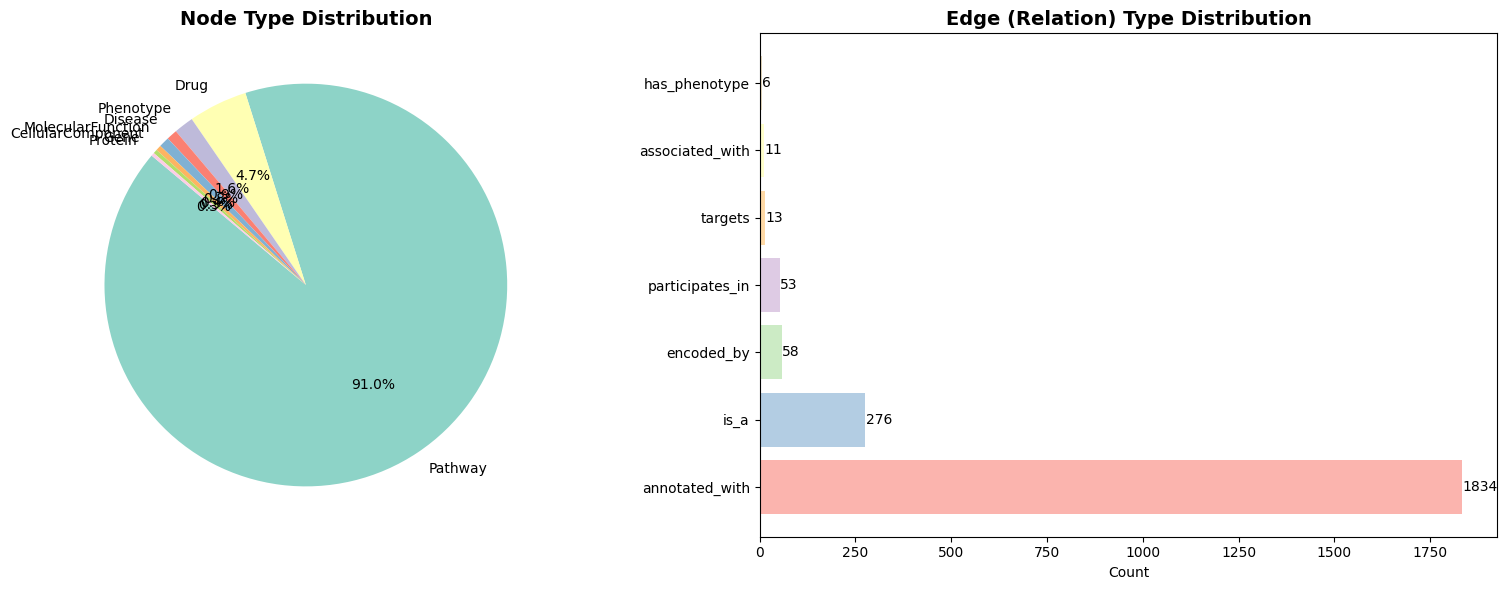

✅ Saved: kg_distribution.png


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Node type pie chart
node_counts = all_nodes['node_type'].value_counts()
axes[0].pie(node_counts.values, labels=node_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=plt.cm.Set3.colors[:len(node_counts)])
axes[0].set_title('Node Type Distribution', fontsize=14, fontweight='bold')

# Edge type bar chart
edge_counts = all_edges['relation'].value_counts()
axes[1].barh(edge_counts.index, edge_counts.values,
             color=plt.cm.Pastel1.colors[:len(edge_counts)])
axes[1].set_xlabel('Count')
axes[1].set_title('Edge (Relation) Type Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(edge_counts.values):
    axes[1].text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/kg_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: kg_distribution.png")

# STEP 18 — Interactive PyVis Visualization (HTML)

In [76]:
from pyvis.network import Network

def visualize_kg_subgraph(G, all_nodes, center_gene='INS', depth=2):
    """
    Creates an interactive HTML visualization of a subgraph
    centered on a given gene, up to N hops away.
    """
    
    # Color map per node type
    COLOR_MAP = {
        'Gene'              : '#4CAF50',   # green
        'Protein'           : '#2196F3',   # blue
        'Drug'              : '#FF5722',   # red-orange
        'Disease'           : '#9C27B0',   # purple
        'Phenotype'         : '#FF9800',   # orange
        'Pathway'           : '#00BCD4',   # cyan
        'MolecularFunction' : '#795548',   # brown
        'CellularComponent' : '#607D8B',   # grey-blue
    }
    
    # Get subgraph: all nodes within 'depth' hops of center_gene
    center_id = f'Gene:{center_gene}'
    if center_id not in G:
        print(f"⚠️  {center_id} not found. Available genes:")
        print([n for n in G.nodes() if n.startswith('Gene:')][:10])
        return
    
    # BFS neighbors
    ego = nx.ego_graph(G.to_undirected(), center_id, radius=depth)
    
    # Limit to 200 nodes for display performance
    nodes_to_show = list(ego.nodes())[:200]
    subG = G.subgraph(nodes_to_show)
    
    # Build PyVis network
    net = Network(height='750px', width='100%',
                  bgcolor='#1a1a2e', font_color='white',
                  notebook=True, cdn_resources='in_line')
    
    net.force_atlas_2based(gravity=-50, spring_length=100)
    
    node_lookup = dict(zip(all_nodes['node_id'], all_nodes['name']))
    type_lookup  = dict(zip(all_nodes['node_id'], all_nodes['node_type']))
    
    for node in subG.nodes():
        label     = node_lookup.get(node, node.split(':')[-1])
        node_type = type_lookup.get(node, 'Unknown')
        color     = COLOR_MAP.get(node_type, '#999999')
        size      = 25 if node == center_id else 15
        
        net.add_node(node, label=label, color=color,
                     title=f"{node_type}: {label}",
                     size=size)
    
    for src, tgt, data in subG.edges(data=True):
        net.add_edge(src, tgt,
                     title=data.get('relation', ''),
                     arrows='to')
    
    # Add legend as HTML title
    net.set_options("""
    {
      "physics": {"enabled": true, "stabilization": {"iterations": 200}},
      "interaction": {"hover": true, "tooltipDelay": 100}
    }
    """)
    
    out_path = f'/kaggle/working/kg_subgraph_{center_gene}.html'
    net.show(out_path)
    print(f"✅ Interactive visualization saved: {out_path}")
    return net

# Visualize subgraph around INS (insulin gene)
net = visualize_kg_subgraph(G, all_nodes, center_gene='INS', depth=2)

/kaggle/working/kg_subgraph_INS.html
✅ Interactive visualization saved: /kaggle/working/kg_subgraph_INS.html


# STEP 19 — Validation

In [77]:
print("=" * 55)
print("✅  KNOWLEDGE GRAPH VALIDATION REPORT")
print("=" * 55)

# 1. Connectivity
components = list(nx.weakly_connected_components(G))
print(f"\n1. Connectivity")
print(f"   Weakly connected components : {len(components)}")
print(f"   Largest component size      : {max(len(c) for c in components)}")

# 2. Degree statistics
degrees = dict(G.degree())
deg_series = pd.Series(degrees)
print(f"\n2. Degree Statistics")
print(f"   Mean degree  : {deg_series.mean():.2f}")
print(f"   Max degree   : {deg_series.max()}")
print(f"   Top 10 hubs  :")
top_hubs = deg_series.nlargest(10)
for node_id, deg in top_hubs.items():
    label = all_nodes.set_index('node_id')['name'].get(node_id, node_id)
    print(f"     {label:25s}  degree={deg}")

# 3. Orphan nodes (no edges)
orphans = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\n3. Orphan nodes (degree=0) : {len(orphans)}")

# 4. Duplicate edges
dup_edges = all_edges.duplicated(['source','target','relation']).sum()
print(f"\n4. Duplicate edges removed : {dup_edges}")

# 5. Schema coverage
print(f"\n5. Node type coverage:")
for ntype, count in all_nodes['node_type'].value_counts().items():
    print(f"   {ntype:25s} : {count}")

# 6. Edge coverage
print(f"\n6. Relation type coverage:")
for rel, count in all_edges['relation'].value_counts().items():
    print(f"   {rel:25s} : {count}")

# 7. Known gene check
print(f"\n7. Core diabetes gene presence check:")
for gene in ['INS','INSR','GCK','PPARG','TCF7L2','LEPR']:
    present = f'Gene:{gene}' in G
    print(f"   Gene:{gene:10s} → {'✅ present' if present else '❌ MISSING'}")

print("\n" + "=" * 55)
print("🎉  Validation complete!")

✅  KNOWLEDGE GRAPH VALIDATION REPORT

1. Connectivity
   Weakly connected components : 20895
   Largest component size      : 1309

2. Degree Statistics
   Mean degree  : 0.20
   Max degree   : 142
   Top 10 hubs  :
     Gene:AKT1                  degree=142
     Gene:MTOR                  degree=142
     Gene:PPARG                 degree=117
     Gene:LEP                   degree=95
     Gene:PRKAA1                degree=88
     Gene:INSR                  degree=85
     Gene:PTPN1                 degree=75
     Gene:INS                   degree=72
     Gene:MAPK1                 degree=71
     Gene:MAPK3                 degree=66

3. Orphan nodes (degree=0) : 20842

4. Duplicate edges removed : 0

5. Node type coverage:
   Pathway                   : 20143
   Drug                      : 1048
   Phenotype                 : 350
   Disease                   : 190
   MolecularFunction         : 184
   CellularComponent         : 98
   Gene                      : 72
   Protein             

# STEP 20 — Final Summary Table

In [78]:
summary = {
    'Component'            : ['Nodes', 'Edges', 'Node Types', 'Relation Types',
                               'Genes', 'Proteins', 'Drugs', 'Diseases',
                               'Phenotypes', 'Pathways'],
    'Count'                : [
        len(all_nodes),
        len(all_edges),
        all_nodes['node_type'].nunique(),
        all_edges['relation'].nunique(),
        (all_nodes['node_type']=='Gene').sum(),
        (all_nodes['node_type']=='Protein').sum(),
        (all_nodes['node_type']=='Drug').sum(),
        (all_nodes['node_type']=='Disease').sum(),
        (all_nodes['node_type']=='Phenotype').sum(),
        all_nodes['node_type'].isin(['Pathway','MolecularFunction','CellularComponent']).sum(),
    ]
}

summary_df = pd.DataFrame(summary)
print("\n📊 DIABETES KNOWLEDGE GRAPH — FINAL SUMMARY")
print(summary_df.to_string(index=False))
summary_df.to_csv('/kaggle/working/kg_summary.csv', index=False)


📊 DIABETES KNOWLEDGE GRAPH — FINAL SUMMARY
     Component  Count
         Nodes  22143
         Edges   2251
    Node Types      8
Relation Types      7
         Genes     72
      Proteins     58
         Drugs   1048
      Diseases    190
    Phenotypes    350
      Pathways  20425


In [82]:
print("""
DATASETS                   NODE TYPES              EDGES
─────────                  ──────────              ─────
gene_info     ──────────►  Gene                    interacts_with (BioGRID)
uniprot.txt   ──────────►  Protein      ◄──────►   encoded_by
chebi.obo     ──────────►  Drug                    targets (Drug→Gene)
doid.obo      ──────────►  Disease                 associated_with (Gene→Disease)
hp.obo        ──────────►  Phenotype               has_phenotype (Disease→Phenotype)
go-basic.obo  ──────────►  Pathway                 annotated_with (Gene→GO)
goa_human.gaf ──────────►  MolFunc/CellComp        participates_in (Gene→KEGG)
biogrid.tab2  ──────────►  (edges only)            is_a (Disease hierarchy)
kegg          ──────────►  Pathway (KEGG)
""")


DATASETS                   NODE TYPES              EDGES
─────────                  ──────────              ─────
gene_info     ──────────►  Gene                    interacts_with (BioGRID)
uniprot.txt   ──────────►  Protein      ◄──────►   encoded_by
chebi.obo     ──────────►  Drug                    targets (Drug→Gene)
doid.obo      ──────────►  Disease                 associated_with (Gene→Disease)
hp.obo        ──────────►  Phenotype               has_phenotype (Disease→Phenotype)
go-basic.obo  ──────────►  Pathway                 annotated_with (Gene→GO)
goa_human.gaf ──────────►  MolFunc/CellComp        participates_in (Gene→KEGG)
biogrid.tab2  ──────────►  (edges only)            is_a (Disease hierarchy)
kegg          ──────────►  Pathway (KEGG)

